In [1]:
print("BUSI")

BUSI


In [2]:

import numpy as np 
import pandas as pd 

import os

dataset_path = "Dataset_BUSI_with_GT"

for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Dataset_BUSI_with_GT\benign\benign (1).png
Dataset_BUSI_with_GT\benign\benign (1)_mask.png
Dataset_BUSI_with_GT\benign\benign (10).png
Dataset_BUSI_with_GT\benign\benign (10)_mask.png
Dataset_BUSI_with_GT\benign\benign (100).png
Dataset_BUSI_with_GT\benign\benign (100)_mask.png
Dataset_BUSI_with_GT\benign\benign (100)_mask_1.png
Dataset_BUSI_with_GT\benign\benign (101).png
Dataset_BUSI_with_GT\benign\benign (101)_mask.png
Dataset_BUSI_with_GT\benign\benign (102).png
Dataset_BUSI_with_GT\benign\benign (102)_mask.png
Dataset_BUSI_with_GT\benign\benign (103).png
Dataset_BUSI_with_GT\benign\benign (103)_mask.png
Dataset_BUSI_with_GT\benign\benign (104).png
Dataset_BUSI_with_GT\benign\benign (104)_mask.png
Dataset_BUSI_with_GT\benign\benign (105).png
Dataset_BUSI_with_GT\benign\benign (105)_mask.png
Dataset_BUSI_with_GT\benign\benign (106).png
Dataset_BUSI_with_GT\benign\benign (106)_mask.png
Dataset_BUSI_with_GT\benign\benign (107).png
Dataset_BUSI_with_GT\benign\benign (107)_mask.png
Data

In [3]:
import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
from torchvision.datasets import ImageFolder

class CleanImageFolder(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform)
        self.samples = [
            (p,y) for p,y in self.samples if "_mask" not in p
        ]

dataset_path = "Dataset_BUSI_with_GT"

dataset = CleanImageFolder(dataset_path, train_transforms)

print(dataset.classes)


['benign', 'malignant', 'normal']


In [7]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

val_ds.dataset.transform = test_transforms
test_ds.dataset.transform = test_transforms

In [8]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = [label for _, label in train_ds]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([0.6026, 1.3094, 1.7333])


In [10]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        # Depthwise
        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, stride=stride,
            padding=1, groups=in_channels
        )
        
        # Pointwise
        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1
        )
        
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [11]:
class ClassicalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            DepthwiseSeparableConv(3, 16, stride=2),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(16, 32, stride=2),
            nn.AdaptiveAvgPool2d((1,1))
        )
        
        self.fc = nn.Linear(32, 3)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [12]:

model = ClassicalCNN().to(device)


### Replacing Convolution Layers with Depthwise Separable Convolution (DSC) Layers

In this code, I replaced the standard convolution layers with Depthwise Separable Convolutions.

Instead of using a single convolution operation, each convolution layer was split into two steps:
- A **depthwise convolution**, which applies filters independently to each input channel
- A **pointwise (1×1) convolution**, which combines the outputs across channels

This change was applied to all convolution layers in the CNN architecture, while keeping the rest of the model (pooling, fully connected layer, training pipeline) unchanged.


In [13]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [14]:
def train(model, loader, epochs=40):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(loader):.4f}")

In [15]:
train(model, train_loader, epochs=40)

Epoch 1/40 - Loss: 1.1434
Epoch 2/40 - Loss: 1.1015
Epoch 3/40 - Loss: 1.0862
Epoch 4/40 - Loss: 1.0759
Epoch 5/40 - Loss: 1.0677
Epoch 6/40 - Loss: 1.0661
Epoch 7/40 - Loss: 1.0592
Epoch 8/40 - Loss: 1.0552
Epoch 9/40 - Loss: 1.0526
Epoch 10/40 - Loss: 1.0497
Epoch 11/40 - Loss: 1.0452
Epoch 12/40 - Loss: 1.0389
Epoch 13/40 - Loss: 1.0314
Epoch 14/40 - Loss: 1.0290
Epoch 15/40 - Loss: 1.0370
Epoch 16/40 - Loss: 1.0338
Epoch 17/40 - Loss: 1.0228
Epoch 18/40 - Loss: 1.0316
Epoch 19/40 - Loss: 1.0124
Epoch 20/40 - Loss: 1.0101
Epoch 21/40 - Loss: 1.0180
Epoch 22/40 - Loss: 1.0159
Epoch 23/40 - Loss: 1.0088
Epoch 24/40 - Loss: 1.0029
Epoch 25/40 - Loss: 0.9924
Epoch 26/40 - Loss: 0.9981
Epoch 27/40 - Loss: 1.0002
Epoch 28/40 - Loss: 0.9938
Epoch 29/40 - Loss: 0.9957
Epoch 30/40 - Loss: 1.0128
Epoch 31/40 - Loss: 0.9925
Epoch 32/40 - Loss: 0.9983
Epoch 33/40 - Loss: 1.0026
Epoch 34/40 - Loss: 0.9970
Epoch 35/40 - Loss: 0.9958
Epoch 36/40 - Loss: 0.9800
Epoch 37/40 - Loss: 0.9859
Epoch 38/4

In [16]:
torch.save(model.state_dict(), "busi_cnn_with_dsc.pth")

In [17]:
def evaluate(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(
        y_true, y_pred,
        target_names=dataset.classes
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=dataset.classes,
                yticklabels=dataset.classes,
                cmap="Blues")
    plt.show()

    unique, counts = np.unique(y_pred, return_counts=True)
    print("Prediction distribution:", dict(zip(unique, counts)))

              precision    recall  f1-score   support

      benign       0.69      0.57      0.63        63
   malignant       0.55      0.67      0.60        43
      normal       0.17      0.18      0.17        11

    accuracy                           0.57       117
   macro avg       0.47      0.48      0.47       117
weighted avg       0.59      0.57      0.58       117



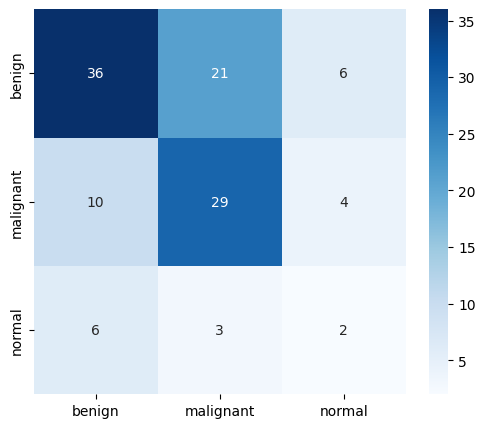

Prediction distribution: {np.int64(0): np.int64(52), np.int64(1): np.int64(53), np.int64(2): np.int64(12)}


In [18]:
evaluate(model, test_loader)

### Implemeting MobileNetV1

In [19]:
class MobileNetV1(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            DepthwiseSeparableConv(32, 64, 1),
            DepthwiseSeparableConv(64, 128, 2),
            DepthwiseSeparableConv(128, 128, 1),
            DepthwiseSeparableConv(128, 256, 2),
            DepthwiseSeparableConv(256, 256, 1),
            DepthwiseSeparableConv(256, 512, 2),

            # simplified version
            DepthwiseSeparableConv(512, 512, 1),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [20]:
mobilenet = MobileNetV1().to(device)

criterion_m = nn.CrossEntropyLoss(weight=class_weights)
optimizer_m = torch.optim.Adam(mobilenet.parameters(), lr=0.0005)

train(mobilenet, train_loader, epochs=40)

Epoch 1/40 - Loss: 1.1042
Epoch 2/40 - Loss: 1.1029
Epoch 3/40 - Loss: 1.1082
Epoch 4/40 - Loss: 1.1076
Epoch 5/40 - Loss: 1.1068
Epoch 6/40 - Loss: 1.1066
Epoch 7/40 - Loss: 1.1004
Epoch 8/40 - Loss: 1.1032
Epoch 9/40 - Loss: 1.1062
Epoch 10/40 - Loss: 1.1017
Epoch 11/40 - Loss: 1.1083
Epoch 12/40 - Loss: 1.1008
Epoch 13/40 - Loss: 1.1069
Epoch 14/40 - Loss: 1.1054
Epoch 15/40 - Loss: 1.1000
Epoch 16/40 - Loss: 1.1011
Epoch 17/40 - Loss: 1.1067
Epoch 18/40 - Loss: 1.1005
Epoch 19/40 - Loss: 1.1039
Epoch 20/40 - Loss: 1.1001
Epoch 21/40 - Loss: 1.1052
Epoch 22/40 - Loss: 1.1049
Epoch 23/40 - Loss: 1.1066
Epoch 24/40 - Loss: 1.1009
Epoch 25/40 - Loss: 1.1061
Epoch 26/40 - Loss: 1.1020
Epoch 27/40 - Loss: 1.1054
Epoch 28/40 - Loss: 1.1043
Epoch 29/40 - Loss: 1.1049
Epoch 30/40 - Loss: 1.0995
Epoch 31/40 - Loss: 1.1056
Epoch 32/40 - Loss: 1.1045
Epoch 33/40 - Loss: 1.1082
Epoch 34/40 - Loss: 1.1012
Epoch 35/40 - Loss: 1.1048
Epoch 36/40 - Loss: 1.1004
Epoch 37/40 - Loss: 1.1060
Epoch 38/4

In [21]:
torch.save(mobilenet.state_dict(), "busi_mobilenetv1.pth")

MobileNetV1 Results:


c:\Users\DELL\anaconda3\envs\mri_project\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\anaconda3\envs\mri_project\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\anaconda3\envs\mri_project\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

              precision    recall  f1-score   support

      benign       0.54      1.00      0.70        63
   malignant       0.00      0.00      0.00        43
      normal       0.00      0.00      0.00        11

    accuracy                           0.54       117
   macro avg       0.18      0.33      0.23       117
weighted avg       0.29      0.54      0.38       117



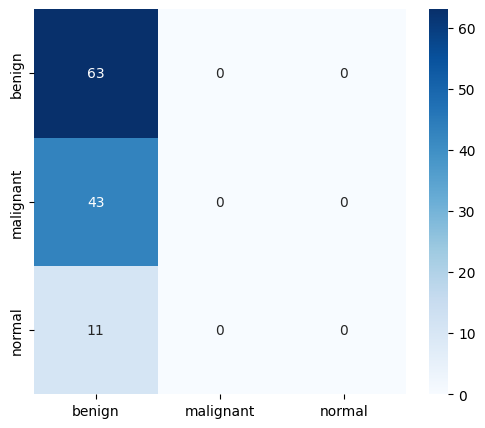

Prediction distribution: {np.int64(0): np.int64(117)}


In [22]:
print("MobileNetV1 Results:")
evaluate(mobilenet, test_loader)